###  Healthcare Readmission Analytics

#### Notebook 02 — Data Cleaning & Preprocessing

##### 
Purpose

This notebook focuses on:

- identifying missing values
- handling hidden missing values
- duplicate analysis
- data quality assessment
- preparing a clean dataset for analysis

Why This Matters

Healthcare data often contains:

- missing values
- inconsistent coding
- duplicate records
- invalid values

Healthcare decisions are sensitive.

Bad data can lead to:

- incorrect business conclusions
- misleading dashboards
- poor machine learning models
- wrong patient risk predictions

In real healthcare analytics projects, data cleaning often takes 60–80% of the project effort.

Cleaning the data improves the reliability of future analysis, machine learning models, and dashboards.

Objective of This Notebook: 
- Load the raw dataset
- Identify hidden missing values (?)
- Analyze missing data
- Check duplicates
- Review data quality issues
- Create a clean dataset
- Save the cleaned dataset

We are not doing feature engineering or ML yet.

#### Step 1: Import Libraries
######
Why We Do This:

Every notebook should be self-contained.

If someone opens only Notebook 02, it should run independently.

Consequence if Skipped: 

Notebook becomes dependent on previously executed notebooks.

This is considered poor practice.

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#### Step 2: Notebook Styling


In [2]:
# ============================================
# VISUAL SETTINGS
# ============================================

sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)

#### Step 3: Load Dataset #####

The raw dataset is loaded directly from the raw data folder.

Using the raw dataset ensures reproducibility and allows us to perform cleaning from the original source.

In [3]:
# ============================================
# LOAD DATA
# ============================================

data_path = "../data/raw/diabetic_data.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)

Shape: (101766, 50)


#### Step 4: Create Working Copy #####

Why We Do This:

Protects the original dataframe.

If something goes wrong, we can restart without reloading.

Consequence if Skipped:

Accidental modifications may affect the original dataset.

In [4]:
# ============================================
# CREATE WORKING COPY
# ============================================

df_clean = df.copy()

print("Working copy created.")

Working copy created.


#### Step 5: Detect Hidden Missing Values #####
Hidden Missing Values

The UCI Diabetes dataset frequently uses "?" instead of actual missing values.

Before analysis, these values must be identified and converted.

In [5]:
# ============================================
# COUNT QUESTION MARKS
# ============================================

question_mark_counts = (df_clean == "?").sum()

question_mark_counts = question_mark_counts[
    question_mark_counts > 0
].sort_values(ascending=False)

question_mark_counts

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

######
It shows how many records contain the value "?", which represents missing or unknown data.
| Column            | Count of "?" | % Missing (Approx.) |
| ----------------- | ------------ | ------------------- |
| weight            | 98,569       | 96.9%               |
| medical_specialty | 49,949       | 49.1%               |
| payer_code        | 40,256       | 39.6%               |
| race              | 2,273        | 2.2%                |
| diag_3            | 1,423        | 1.4%                |
| diag_2            | 358          | 0.35%               |
| diag_1            | 21           | 0.02%               |

Total records = 101,766

Why We Do This:

df.info() showed no missing values.

However, "?" is being treated as text.

This hides missing data from standard analysis.

Consequence if Skipped:

Missing value analysis becomes completely inaccurate.

#### Step 6: Convert ? to Missing Values 
(because Python understands NaN but not ?)

In [6]:
# ============================================
# REPLACE ? WITH NaN
# ============================================

df_clean.replace("?", np.nan, inplace=True)

print("Question marks replaced with NaN.")

Question marks replaced with NaN.


#### Step 7: Missing Value Analysis

In [7]:
# ============================================
# MISSING VALUE COUNTS
# ============================================

missing_count = df_clean.isnull().sum()

missing_count = missing_count[
    missing_count > 0
].sort_values(ascending=False)

missing_count

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [8]:
# ============================================
# MISSING VALUE PERCENTAGES
# ============================================

missing_percent = (
    df_clean.isnull().mean() * 100
).round(2)

missing_percent = missing_percent[
    missing_percent > 0
].sort_values(ascending=False)

missing_percent

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

Why We Do This:
Counts alone can be misleading.

Percentages help determine:
- drop column
- keep column
- impute values

#### Step 8: Missing Value Visualization
#####
Visuals quickly identify problem columns.

Recruiters and stakeholders also understand charts faster.

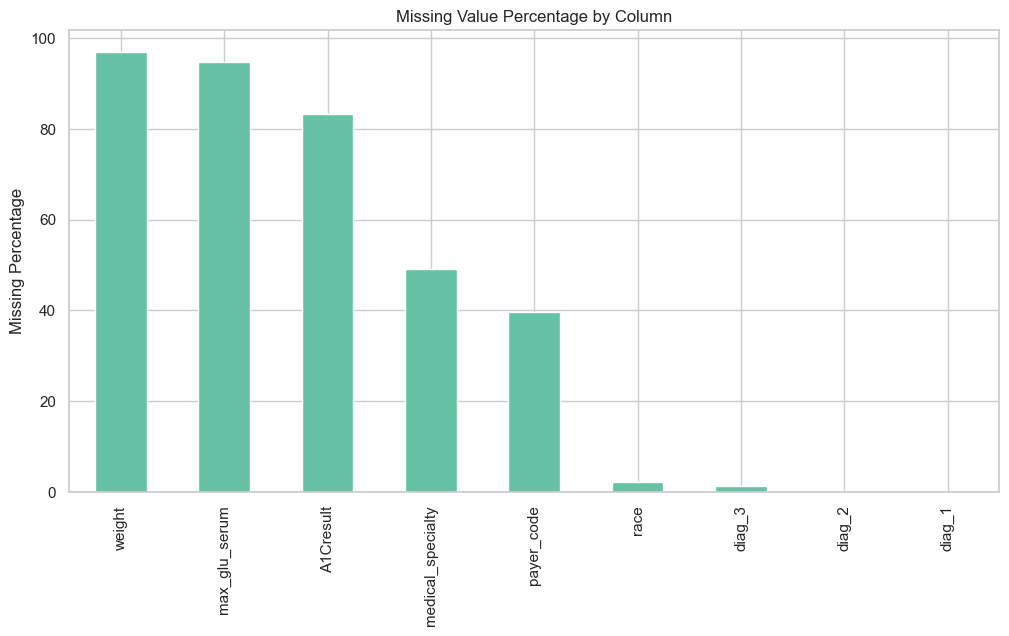

In [9]:
# ============================================
# MISSING VALUE VISUALIZATION
# ============================================

missing_percent.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing Percentage")
plt.show()

#### Step 9: Duplicate Check
#####
Duplicate records may inflate counts and distort business metrics.

Healthcare datasets should be checked for duplicate encounters.

In [10]:
# ============================================
# DUPLICATE CHECK
# ============================================

duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


#### Step 10: Unique Patient Analysis
#####
Healthcare datasets often contain: 
multiple encounters per patient

This is important for future ML and readmission analysis.

In [11]:
# ============================================
# DATA QUALITY SUMMARY
# ============================================

summary = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percent":
        round(df_clean.isnull().mean()*100,2)
})

summary.sort_values(
    by="missing_percent",
    ascending=False
).head(15)

,missing_count,missing_percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
patient_nbr,0,0.00


#### Step 11: Save Clean Dataset

In [12]:
# ============================================
# SAVE CLEAN DATASET
# ============================================

output_path = "../data/processed/cleaned_healthcare_data.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Clean dataset saved.")

Clean dataset saved.


#### Key Findings

##### Missing Values

- Hidden missing values were identified using "?"
- Missing values were converted to NaN

##### Data Quality

- Duplicate records were evaluated
- Unique patient counts were reviewed

##### Dataset Status

The dataset is now ready for:

- exploratory analysis
- SQL analytics
- feature engineering
- machine learning preparation

##### Next Steps

Notebook 03 will focus on:

- healthcare exploratory data analysis
- readmission patterns
- demographic analysis
- hospital utilization trends